<a href="https://colab.research.google.com/github/BrenoMafra13/COMP3132-Machine_Learning/blob/main/assignments/assign4_Breno.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Assignment 4 - Breno Lopes Mafra (ID: 101485572)
#DataSet: CIFAR10 DATA

1) Data Preparation

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
# Loading and normalizing the dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


2) Train, validation, test set splits

In [3]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

# Encoding labels
y_train = tf.keras.utils.to_categorical(y_train)
y_val = tf.keras.utils.to_categorical(y_val)
y_test = tf.keras.utils.to_categorical(y_test)

3) L1, L2, or Dropout Regularization

In [4]:
model_regularized = models.Sequential([
    layers.Conv2D(32, (3, 3),
                  activation='relu',
                  kernel_regularizer=regularizers.l2(0.001),
                  input_shape=(32, 32, 3)),
    layers.Conv2D(64, (3, 3),
                  activation='relu',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.Flatten(),
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),

    #Dropout to prevent overfitting
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_regularized.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_regularized = model_regularized.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(x_val, y_val)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.3291 - loss: 1.9323 - val_accuracy: 0.4649 - val_loss: 1.6144
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4058 - loss: 1.7460 - val_accuracy: 0.4855 - val_loss: 1.5905
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4335 - loss: 1.6859 - val_accuracy: 0.5165 - val_loss: 1.5417
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4539 - loss: 1.6469 - val_accuracy: 0.5382 - val_loss: 1.4639
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4800 - loss: 1.5999 - val_accuracy: 0.5601 - val_loss: 1.4134


4) Overparameterization (too many weights)

In [5]:
model_overfit = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    # Using a very large dense layer to increase weights significantly
    layers.Dense(512, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_overfit.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Training for enough epochs to see the overfitting gap
history_overfit = model_overfit.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_val, y_val)
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.5149 - loss: 1.3668 - val_accuracy: 0.6077 - val_loss: 1.1040
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6862 - loss: 0.9043 - val_accuracy: 0.6630 - val_loss: 0.9709
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7925 - loss: 0.6004 - val_accuracy: 0.6747 - val_loss: 0.9711
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9002 - loss: 0.2973 - val_accuracy: 0.6700 - val_loss: 1.1759
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9651 - loss: 0.1128 - val_accuracy: 0.6621 - val_loss: 1.4918
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9839 - loss: 0.0540 - val_accuracy: 0.6547 - val_loss: 1.7755
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9856 - loss: 0.0481 - val_accuracy: 0.6521 - val_loss: 1.9597
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9833 - loss: 0.0521 - val_acc

5) Data Augmentation

In [6]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

model_final = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3, 3),
                  activation='relu',
                  kernel_regularizer=regularizers.l2(0.001),
                  input_shape=(32, 32, 3)),
    layers.Conv2D(64, (3, 3),
                  activation='relu',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.Flatten(),
    layers.Dense(64,
                 activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),

    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_final.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_final = model_final.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(x_val, y_val)
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.3006 - loss: 1.9898 - val_accuracy: 0.4402 - val_loss: 1.6720
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.3635 - loss: 1.8397 - val_accuracy: 0.4308 - val_loss: 1.6611
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3850 - loss: 1.7975 - val_accuracy: 0.4833 - val_loss: 1.5904
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.3954 - loss: 1.7650 - val_accuracy: 0.4758 - val_loss: 1.5587
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4022 - loss: 1.7503 - val_accuracy: 0.4913 - val_loss: 1.5259


6) Convnets

In [7]:
model_final.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (64, 32, 32, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (64, 30, 30, 32)       │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (64, 28, 28, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (64, 50176)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (64, 64)               │     3,211,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (64, 64)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (64, 10)               │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,694,112 (36.98 MB)

 Trainable params: 3,231,370 (12.33 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,462,742 (24.65 MB)

7) Number of epochs required for acceptable metrics

In [8]:
final_accuracy = history_final.history['val_accuracy'][-1]
print(f"Final Validation Accuracy: {final_accuracy:.4f}")

Final Validation Accuracy: 0.4913


8) Graphics

In [9]:
def plot_comparison(history_bad, history_good):
    plt.figure(figsize=(14, 10))

    # 1. Accuracy Graph - Overfitted Model
    plt.subplot(2, 2, 1)
    plt.plot(history_bad.history['accuracy'], label='Train Acc')
    plt.plot(history_bad.history['val_accuracy'], label='Val Acc')
    plt.title('1. Overfitted Model - Accuracy')
    plt.legend()

    # 2. Loss Graph - Overfitted Model
    plt.subplot(2, 2, 2)
    plt.plot(history_bad.history['loss'], label='Train Loss')
    plt.plot(history_bad.history['val_loss'], label='Val Loss')
    plt.title('2. Overfitted Model - Loss')
    plt.legend()

    # 3. Accuracy Graph - Improved Model
    plt.subplot(2, 2, 3)
    plt.plot(history_good.history['accuracy'], label='Train Acc')
    plt.plot(history_good.history['val_accuracy'], label='Val Acc')
    plt.title('3. Improved Model (Augmentation + Reg) - Accuracy')
    plt.legend()

    # 4. Loss Graph - Improved Model
    plt.subplot(2, 2, 4)
    plt.plot(history_good.history['loss'], label='Train Loss')
    plt.plot(history_good.history['val_loss'], label='Val Loss')
    plt.title('4. Improved Model (Augmentation + Reg) - Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()


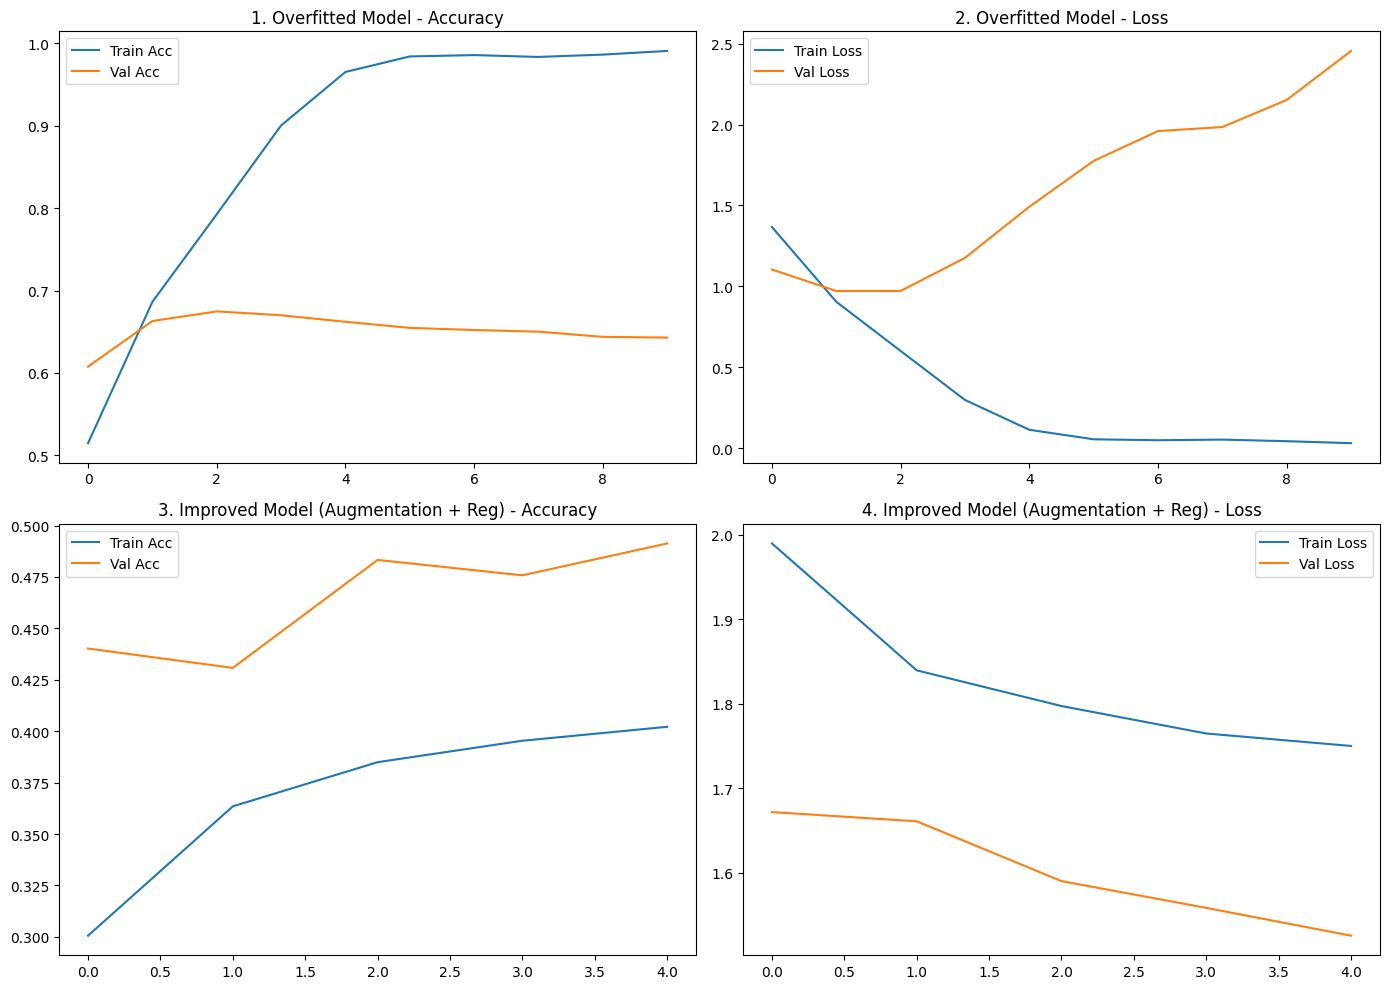

In [10]:
plot_comparison(history_overfit, history_final)